# Trying to check if a Leaky ReLU Neuron can have a brain damage in case of a very high learning rate?

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open("names.txt", "r").read().splitlines()
print(f'Total Names: {len(words)}')
print(f'First 8 names: {words[:8]}')

chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."]=0
itos={i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'Indexes to string dict: {itos}')
print(f'Len of Indexes to string dictionary (i.e Vocabulary size): {vocab_size}')

Total Names: 32033
First 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Indexes to string dict: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Len of Indexes to string dictionary (i.e Vocabulary size): 27


In [2]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0]*block_size
        for char in word + ".":
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(f'X-Shape:{X.shape}, Y-shape:{Y.shape}')
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) #10%


X-Shape:torch.Size([182625, 3]), Y-shape:torch.Size([182625])
X-Shape:torch.Size([22655, 3]), Y-shape:torch.Size([22655])
X-Shape:torch.Size([22866, 3]), Y-shape:torch.Size([22866])


In [6]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 11897


In [7]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = F.leaky_relu(hpreact, negative_slope=0.01) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 1 # Extreme high learning rate
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.5515
  10000/ 200000:nan
  20000/ 200000:nan
  30000/ 200000:nan
  40000/ 200000:nan
  50000/ 200000:nan
  60000/ 200000:nan
  70000/ 200000:nan
  80000/ 200000:nan
  90000/ 200000:nan
 100000/ 200000:nan
 110000/ 200000:nan
 120000/ 200000:nan
 130000/ 200000:nan
 140000/ 200000:nan
 150000/ 200000:nan
 160000/ 200000:nan
 170000/ 200000:nan
 180000/ 200000:nan
 190000/ 200000:nan


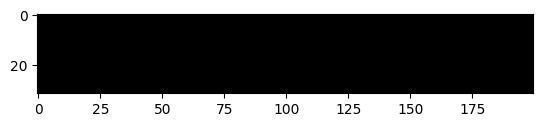

In [8]:
plt.Figure(figsize=(20, 10))
plt.imshow(h.abs()>0.99, cmap="gray", interpolation="nearest")

### Conclusion: I think I am not doing the experiments correctly I'll complete the chapter and then ask chatgpt. 